# Fase 6 — Clasificación Zero-Shot con LLM
## Experimento: Knowledge Graph UAM-Azcapotzalco

**Objetivo:** Clasificar los 746 artículos UAM-A (en inglés) en 10 categorías cs.* de arXiv usando un LLM en modo zero-shot, sin ningún entrenamiento supervisado sobre datos UAM-A.

**Diseño experimental:** Transferencia pura desde arXiv → UAM-A. El zero-shot sirve como baseline moderno y punto de comparación contra BiLSTM (Fase 4) y SciBERT+LoRA (Fase 5).



In [18]:
# ============================================================
# CELDA 1 — Imports y configuración
# ============================================================

import os
import re
import json
import time
import random
import warnings
import logging
from abc import ABC, abstractmethod
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

now       = datetime.now()
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

#  Bloque de configuración 
# Rutas
UAM_PATH        = "uam_a_dataset.parquet"           # 746 artículos en inglés
BILSTM_PATH     = "bilstm_optuna_predictions_uam_02_04_2026_14_08_04.parquet"  # predicciones Fase 4
SCIBERT_PATH    = "scibert_predictions_uam_03_04_2026_03_02_07.parquet" # predicciones Fase 5

PREDS_PATH      = f"zeroshot_predictions_uam_{date_time}.parquet"
CHECKPOINT_PATH = f"zeroshot_checkpoint_{date_time}.parquet"
METRICS_PATH    = f"zeroshot_metrics_{date_time}.json"

# Configuración del LLM

PROVIDER    = "ollama"
#MODEL_NAME  = "deepseek-r1:7b"   # o deepseek-r1:14b 
MODEL_NAME  = "deepseek-r1:14b"
OLLAMA_MODEL = "deepseek-r1:14b"  # debe coincidir con MODEL_NAME

TEMPERATURE     = 0.0               # determinismo total — NO cambiar
MAX_TOKENS      = 512 #20                # respuesta esperada: solo código cs.*
BATCH_SIZE      = 10                # documentos por lote
CHECKPOINT_FREQ = 50                # guardar checkpoint cada N artículos
RANDOM_SEED     = 42


OLLAMA_BASE_URL = "http://localhost:11434"
#OLLAMA_MODEL    = "llama3.1:8b"     # alternativas: mistral:7b, phi3:mini

# Las 10 categorías del experimento
CATEGORIES = {
    "cs.AI": "Artificial Intelligence",
    "cs.CL": "Computation and Language (NLP)",
    "cs.CR": "Cryptography and Security",
    "cs.CV": "Computer Vision and Pattern Recognition",
    "cs.DS": "Data Structures and Algorithms",
    "cs.IT": "Information Theory",
    "cs.LG": "Machine Learning",
    "cs.NA": "Numerical Analysis",
    "cs.RO": "Robotics",
    "cs.SY": "Systems and Control",
}
VALID_CODES = set(CATEGORIES.keys())

# Fijar semilla para reproducibilidad
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(" Configuración cargada.")
print(f"   Proveedor : {PROVIDER}")
print(f"   Modelo    : {MODEL_NAME}")
print(f"   Temp.     : {TEMPERATURE}")
print(f"   Max tokens: {MAX_TOKENS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Checkpoint: cada {CHECKPOINT_FREQ} artículos")

 Configuración cargada.
   Proveedor : ollama
   Modelo    : deepseek-r1:14b
   Temp.     : 0.0
   Max tokens: 512
   Batch size: 10
   Checkpoint: cada 50 artículos


In [3]:
# ============================================================
# CELDA 2 — Carga del dataset UAM-A
# ============================================================

df_uam = pd.read_parquet(UAM_PATH)
print(f"Filas: {len(df_uam)} | Columnas: {list(df_uam.columns)}")

assert len(df_uam) == 746, f"Se esperaban 746 artículos, hay {len(df_uam)}."

# Columna de abstract
ABSTRACT_COL = "Resumen"
assert ABSTRACT_COL in df_uam.columns, f"Columna '{ABSTRACT_COL}' no encontrada."

# Rellenar nulos
mask_null = df_uam[ABSTRACT_COL].isna() | (df_uam[ABSTRACT_COL].str.strip() == "")
df_uam.loc[mask_null, ABSTRACT_COL] = ""
print(f"Abstracts nulos rellenados: {mask_null.sum()}")

# Etiqueta manual (opcional — para Celda 8)
LABEL_COL = "etiqueta_manual" if "etiqueta_manual" in df_uam.columns else None
print(f"Etiqueta manual: {'encontrada' if LABEL_COL else 'no disponible'}")

Filas: 746 | Columnas: ['Resumen', 'lang', 'pred_scibert_idx', 'pred_scibert']
Abstracts nulos rellenados: 0
Etiqueta manual: no disponible


In [9]:
# ============================================================
# CELDA 3 — Diseño del prompt
# ============================================================

def build_prompt(abstract: str) -> str:
    """
    Construye el prompt de clasificación zero-shot para un abstract dado.
    
    Incluye:
    - Definición del rol del modelo
    - Lista de 10 categorías con código y descripción
    - Instrucciones explícitas de formato de respuesta
    - Dos ejemplos few-shot para anclar el formato (válidos en zero-shot:
      guían el formato de salida, no el conocimiento de la tarea)
    - El abstract a clasificar
    """
    # Construir lista de categorías
    cat_lines = "\n".join(
        f"  - {code}: {desc}" for code, desc in CATEGORIES.items()
    )
    
    prompt = f"""You are a scientific paper classifier specialized in Computer Science.
Your task is to assign exactly one category to the paper abstract below.

Available categories:
{cat_lines}

Rules:
  - Respond with ONLY the category code (e.g., cs.LG)
  - Do not include any explanation, punctuation, or extra text
  - Do not repeat the abstract or the category name
  - If uncertain, choose the single most likely category

Examples:
Abstract: "We propose a novel convolutional neural architecture for real-time semantic image segmentation using encoder-decoder design with skip connections."
Category: cs.CV

Abstract: "We introduce a gradient-based optimization method for training deep neural networks with adaptive learning rate schedules that improve convergence."
Category: cs.LG

Abstract to classify:
{abstract.strip()}
Category:"""
    return prompt


#  Mostrar prompt completo para un abstract de ejemplo 
EXAMPLE_ABSTRACT = (
    "This paper presents a robust Kalman filter formulation for state estimation "
    "in nonlinear dynamical systems under bounded noise. We derive sufficient "
    "conditions for stability and demonstrate the approach on aerospace control problems."
)

example_prompt = build_prompt(EXAMPLE_ABSTRACT)

print("═" * 65)
print("PROMPT COMPLETO (abstract de ejemplo — respuesta esperada: cs.SY)")
print("═" * 65)
print(example_prompt)
print("═" * 65)
print(f"\nLongitud del prompt: {len(example_prompt)} caracteres")
print(f"Tokens estimados (aprox. /4): {len(example_prompt) // 4} tokens")

═════════════════════════════════════════════════════════════════
PROMPT COMPLETO (abstract de ejemplo — respuesta esperada: cs.SY)
═════════════════════════════════════════════════════════════════
You are a scientific paper classifier specialized in Computer Science.
Your task is to assign exactly one category to the paper abstract below.

Available categories:
  - cs.AI: Artificial Intelligence
  - cs.CL: Computation and Language (NLP)
  - cs.CR: Cryptography and Security
  - cs.CV: Computer Vision and Pattern Recognition
  - cs.DS: Data Structures and Algorithms
  - cs.IT: Information Theory
  - cs.LG: Machine Learning
  - cs.NA: Numerical Analysis
  - cs.RO: Robotics
  - cs.SY: Systems and Control

Rules:
  - Respond with ONLY the category code (e.g., cs.LG)
  - Do not include any explanation, punctuation, or extra text
  - Do not repeat the abstract or the category name
  - If uncertain, choose the single most likely category

Examples:
Abstract: "We propose a novel convolutional 

In [11]:
# ============================================================
# CELDA 4 — Clientes LLM e interfaz de inferencia
# ============================================================


import re
import time
import requests

def build_prompt(abstract: str) -> str:
    cat_lines = "\n".join(f"  - {code}: {desc}" for code, desc in CATEGORIES.items())
    return f"""You are a scientific paper classifier specialized in Computer Science.
Assign exactly one category to the abstract below.

Available categories:
{cat_lines}

Rules:
  - Respond with ONLY the category code (e.g., cs.LG)
  - No explanation, no punctuation, no extra text

Examples:
Abstract: "We propose a convolutional architecture for semantic image segmentation."
Category: cs.CV

Abstract: "We introduce an adaptive learning rate method for training deep networks."
Category: cs.LG

Abstract to classify:
{abstract.strip()}
Category:"""


def _parse(raw: str) -> str:
    """Extrae cs.XX ignorando el bloque <think> de DeepSeek."""
    # Eliminar bloque de razonamiento interno
    clean = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
    match = re.search(r'\b(cs\.[A-Z]{2})\b', clean)
    if match:
        code = match.group(1)
        return code if code in VALID_CODES else "INVALID"
    return "INVALID"


def classify(abstract: str) -> tuple[str, str]:
    """Clasifica un abstract. Devuelve (etiqueta, respuesta_cruda)."""
    prompt = build_prompt(abstract)
    
    for delay in [1, 2, 4, 8, 16]:
        try:
            resp = requests.post(
                f"{OLLAMA_BASE_URL}/api/generate",
                json={
                    "model": OLLAMA_MODEL,
                    "prompt": prompt,
                    "stream": False,
                    "options": {
                        "temperature": TEMPERATURE,
                        "num_predict": MAX_TOKENS,
                    }
                },
                timeout=120
            )
            resp.raise_for_status()
            raw = resp.json()["response"].strip()
            label = _parse(raw)
            
            # Segundo intento simplificado si falla el parseo
            if label == "INVALID":
                simple = (
                    f"Choose one: {', '.join(sorted(VALID_CODES))}\n"
                    f"Abstract: {abstract[:400]}\nCode:"
                )
                resp2 = requests.post(
                    f"{OLLAMA_BASE_URL}/api/generate",
                    json={"model": OLLAMA_MODEL, "prompt": simple,
                          "stream": False, "options": {"temperature": 0.0, "num_predict": 10}},
                    timeout=120
                )
                raw2 = resp2.json()["response"].strip()
                label = _parse(raw2)
                return label, f"[retry] {raw2}"
            
            return label, raw

        except requests.exceptions.Timeout:
            print(f"  Timeout. Reintentando en {delay}s...")
            time.sleep(delay)
        except Exception as e:
            print(f"  Error: {e}. Reintentando en {delay}s...")
            time.sleep(delay)
    
    return "INVALID", "ERROR: max retries exceeded"


# Prueba rápida
print("Probando conexión con Ollama...")
test_label, test_raw = classify("We propose a Kalman filter for state estimation in nonlinear control systems.")
print(f"Predicción: {test_label}")
print(f"Respuesta cruda: {test_raw!r}")

Probando conexión con Ollama...
Predicción: cs.SY
Respuesta cruda: 'cs.SY'


In [28]:
# ============================================================
# CELDA 4 — Clientes LLM e interfaz de inferencia
# ============================================================


import re
import time
import requests

def build_prompt(abstract: str) -> str:
    cat_lines = "\n".join(f"  - {code}: {desc}" for code, desc in CATEGORIES.items())
    return f"""You are a scientific paper classifier specialized in Computer Science.
Assign exactly one category to the abstract below.

Available categories:
{cat_lines}

Rules:
  - Respond with ONLY the category code (e.g., cs.LG)
  - No explanation, no punctuation, no extra text

Examples:
Abstract: "We propose a convolutional architecture for semantic image segmentation."
Category: cs.CV

Abstract: "We introduce an adaptive learning rate method for training deep networks."
Category: cs.LG

Abstract to classify:
{abstract.strip()}
Category:"""


def _parse(raw: str) -> str:
    """Extrae cs.XX ignorando el bloque <think> de DeepSeek."""
    # Eliminar bloque de razonamiento interno
    clean = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
    match = re.search(r'\b(cs\.[A-Z]{2})\b', clean)
    if match:
        code = match.group(1)
        return code if code in VALID_CODES else "INVALID"
    return "INVALID"


def classify(abstract: str) -> tuple[str, str]:
    """Clasifica un abstract. Devuelve (etiqueta, respuesta_cruda)."""
    prompt = build_prompt(abstract)
    
    for delay in [1, 2, 4, 8, 16]:
        try:
            resp = requests.post(
                f"{OLLAMA_BASE_URL}/api/generate",
                json={
                    "model": OLLAMA_MODEL,
                    "prompt": prompt,
                    "stream": False,
                    "options": {
                        "temperature": TEMPERATURE,
                        "num_predict": MAX_TOKENS,
                    }
                },
                timeout=120
            )
            resp.raise_for_status()
            raw = resp.json()["response"].strip()
            label = _parse(raw)
            
            # Segundo intento simplificado si falla el parseo
            if label == "INVALID":
                simple = (
                    f"You must choose exactly one category even if the abstract is not a perfect fit.\n"
                    f"Choose the closest one from: {', '.join(sorted(VALID_CODES))}\n"
                    f"Abstract: {abstract[:400]}\n"
                    f"Respond with ONLY the code. Category:"
                )
                resp2 = requests.post(
                    f"{OLLAMA_BASE_URL}/api/generate",
                    json={"model": OLLAMA_MODEL, "prompt": simple,
                          "stream": False, "options": {"temperature": 0.0, "num_predict": 10}},
                    timeout=120
                )
                raw2 = resp2.json()["response"].strip()
                label = _parse(raw2)
                return label, f"[retry] {raw2}", True   # tercer valor = retry_flag
            
            return label, raw, False

        except requests.exceptions.Timeout:
            print(f"  Timeout. Reintentando en {delay}s...")
            time.sleep(delay)
        except Exception as e:
            print(f"  Error: {e}. Reintentando en {delay}s...")
            time.sleep(delay)
    
    return "INVALID", "ERROR: max retries exceeded"


# Prueba rápida
print("Probando conexión con Ollama...")
test_label, test_raw = classify("We propose a Kalman filter for state estimation in nonlinear control systems.")
print(f"Predicción: {test_label}")
print(f"Respuesta cruda: {test_raw!r}")

Probando conexión con Ollama...


ValueError: too many values to unpack (expected 2)

In [27]:
# Eliminar INVALID del checkpoint para que sean reprocesados
checkpoint_file = Path(CHECKPOINT_PATH)
if checkpoint_file.exists():
    df_ckpt = pd.read_parquet(checkpoint_file)
    df_ckpt_clean = df_ckpt[df_ckpt["pred_zeroshot"] != "INVALID"]
    df_ckpt_clean.to_parquet(checkpoint_file, index=True)
    print(f"Checkpoint limpiado. Quedan {len(df_ckpt_clean)} artículos válidos.")
    print(f"Se reprocesarán: {len(df_ckpt) - len(df_ckpt_clean)} artículos INVALID.")

Checkpoint limpiado. Quedan 596 artículos válidos.
Se reprocesarán: 104 artículos INVALID.


In [21]:
# ============================================================
# CELDA 5 — Inferencia por lotes sobre UAM-A con checkpoint
# ============================================================
df_uam["retry_flag"] = False  # inicializar

#  Verificar si existe checkpoint para retomar 
checkpoint_file = Path(CHECKPOINT_PATH)
if checkpoint_file.exists():
    df_checkpoint = pd.read_parquet(checkpoint_file)
    done_indices = set(df_checkpoint.index.tolist())
    print(f"  Checkpoint encontrado. Artículos ya procesados: {len(done_indices)}")
    print(f"   Retomando desde el artículo {len(done_indices)}...")
else:
    df_checkpoint = pd.DataFrame()
    done_indices = set()
    print(" Sin checkpoint previo. Iniciando desde cero.")

#  Preparar resultados 
results = {}
# Cargar resultados previos del checkpoint si existen
if not df_checkpoint.empty:
    for idx, row in df_checkpoint.iterrows():
        results[idx] = {
            "pred_zeroshot":  row.get("pred_zeroshot", "INVALID"),
            "raw_response":   row.get("raw_response", ""),
            "inference_time": row.get("inference_time", 0.0),
        }

#  Identificar artículos pendientes 
pending_mask = ~df_uam.index.isin(done_indices)
df_pending = df_uam[pending_mask].copy()
print(f"\n Artículos pendientes: {len(df_pending)} / {len(df_uam)}")

# ──Inferencia por lotes 
n_invalid = 0
total_start = time.time()
processed_since_checkpoint = 0

indices_list = df_pending.index.tolist()

print(f"\n Iniciando inferencia con {PROVIDER}/{MODEL_NAME} (batch={BATCH_SIZE})...")
print(f"   Checkpoint cada {CHECKPOINT_FREQ} artículos.\n")

with tqdm(total=len(indices_list), desc="Clasificando", unit="art") as pbar:
    for batch_start in range(0, len(indices_list), BATCH_SIZE):
        batch_indices = indices_list[batch_start : batch_start + BATCH_SIZE]

        for idx in batch_indices:
            abstract = str(df_uam.loc[idx, ABSTRACT_COL])

            t0 = time.time()
            try:
                label, raw = classify(abstract)
            except Exception as e:
                label, raw = "INVALID", f"EXCEPTION: {e}"
            t1 = time.time()

            if label == "INVALID":
                n_invalid += 1

            results[idx] = {
                "pred_zeroshot":  label,
                "raw_response":   raw,
                "inference_time": round(t1 - t0, 3),
            }
            processed_since_checkpoint += 1
            pbar.update(1)

            #  Checkpoint cada CHECKPOINT_FREQ artículos 
            if processed_since_checkpoint % CHECKPOINT_FREQ == 0:
                df_ckpt = df_uam.copy()
                df_ckpt["pred_zeroshot"]  = df_ckpt.index.map(lambda i: results.get(i, {}).get("pred_zeroshot", np.nan))
                df_ckpt["raw_response"]   = df_ckpt.index.map(lambda i: results.get(i, {}).get("raw_response", np.nan))
                df_ckpt["inference_time"] = df_ckpt.index.map(lambda i: results.get(i, {}).get("inference_time", np.nan))
                df_ckpt_done = df_ckpt[df_ckpt["pred_zeroshot"].notna()]
                df_ckpt_done.to_parquet(checkpoint_file, index=True)
                tqdm.write(f"   Checkpoint guardado ({len(df_ckpt_done)} artículos procesados)")

        # Pausa corta entre lotes para control de rate limit
        time.sleep(0.1)

total_time = time.time() - total_start

#  Montar DataFrame final 
df_uam["pred_zeroshot"]  = df_uam.index.map(lambda i: results[i]["pred_zeroshot"])
df_uam["raw_response"]   = df_uam.index.map(lambda i: results[i]["raw_response"])
df_uam["inference_time"] = df_uam.index.map(lambda i: results[i]["inference_time"])

#  Reporte final 
n_total     = len(df_uam)
pct_invalid = 100 * n_invalid / n_total
avg_time    = df_uam["inference_time"].mean()

print("\n" + "═" * 55)
print("REPORTE DE INFERENCIA")
print("═" * 55)
print(f"  Total artículos procesados : {n_total}")
print(f"  Respuestas INVALID         : {n_invalid} ({pct_invalid:.1f}%)")
print(f"  Tiempo total               : {total_time / 60:.2f} min")
print(f"  Tiempo promedio por artículo: {avg_time:.2f}s")


 Sin checkpoint previo. Iniciando desde cero.

 Artículos pendientes: 746 / 746

 Iniciando inferencia con ollama/deepseek-r1:14b (batch=10)...
   Checkpoint cada 50 artículos.



Clasificando:   0%|          | 0/746 [00:00<?, ?art/s]

   Checkpoint guardado (50 artículos procesados)
   Checkpoint guardado (100 artículos procesados)
   Checkpoint guardado (150 artículos procesados)
   Checkpoint guardado (200 artículos procesados)
   Checkpoint guardado (250 artículos procesados)
   Checkpoint guardado (300 artículos procesados)
   Checkpoint guardado (350 artículos procesados)
   Checkpoint guardado (400 artículos procesados)
   Checkpoint guardado (450 artículos procesados)
   Checkpoint guardado (500 artículos procesados)
   Checkpoint guardado (550 artículos procesados)
   Checkpoint guardado (600 artículos procesados)
   Checkpoint guardado (650 artículos procesados)
   Checkpoint guardado (700 artículos procesados)

═══════════════════════════════════════════════════════
REPORTE DE INFERENCIA
═══════════════════════════════════════════════════════
  Total artículos procesados : 746
  Respuestas INVALID         : 113 (15.1%)
  Tiempo total               : 62.45 min
  Tiempo promedio por artículo: 5.01s


 Distribución de predicciones Zero-Shot:
pred_zeroshot
cs.NA      149
cs.AI      118
INVALID    113
cs.SY      109
cs.DS       92
cs.LG       58
cs.CL       47
cs.CV       38
cs.IT        9
cs.CR        7
cs.RO        6

 Predicciones SciBERT cargadas desde 'scibert_predictions_uam_03_04_2026_03_02_07.parquet'.

 Tabla comparativa de distribuciones por modelo:
           BiLSTM SciBERT+LoRA  Zero-Shot
Categoría                                
cs.AI         216            —        118
cs.CL          16            —         47
cs.CR          22            —          7
cs.CV           8            —         38
cs.DS         103            —         92
cs.IT           5            —          9
cs.LG           0            —         58
cs.NA         185            —        149
cs.RO          18            —          6
cs.SY         173            —        109

 Análisis cs.LG:
   BiLSTM predijo cs.LG     : 0 veces (0%)
   SciBERT+LoRA predijo cs.LG: 0 veces
   Zero-Shot predijo cs.LG  : 58 

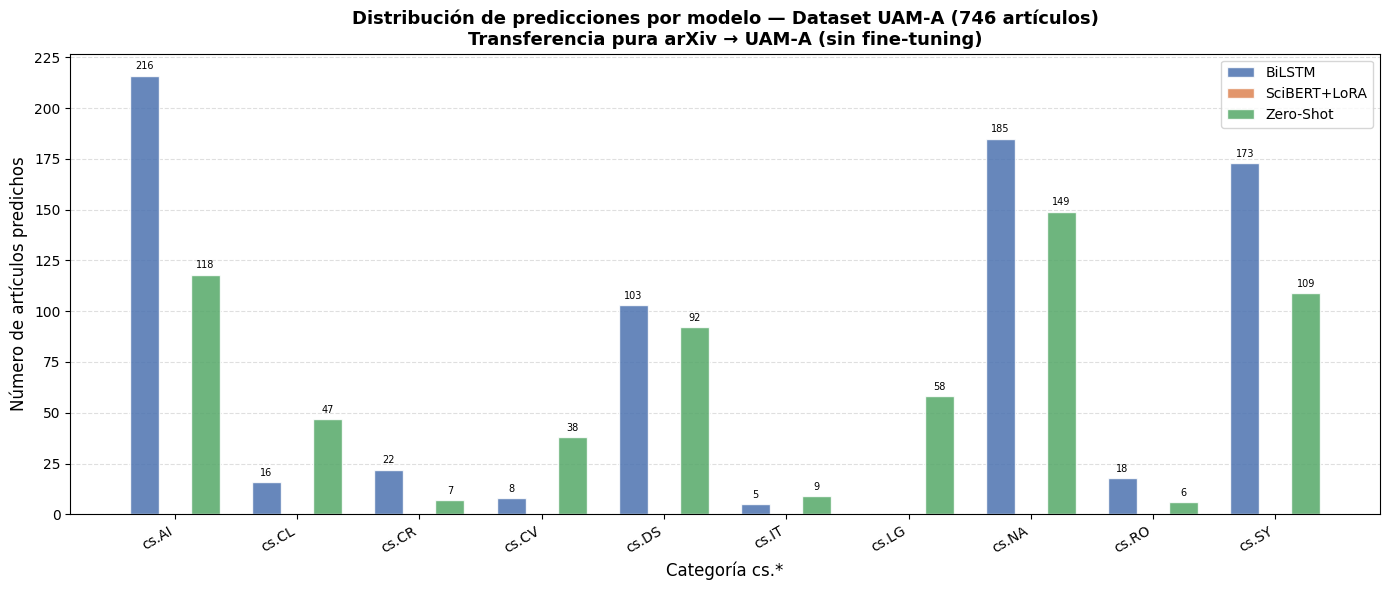

 Gráfico guardado: zeroshot_distribucion_comparativa.png


In [22]:
# ============================================================
# CELDA 6 — Análisis de predicciones y comparación de distribuciones
# ============================================================

#  Distribución zero-shot 
zs_dist = df_uam["pred_zeroshot"].value_counts()
print(" Distribución de predicciones Zero-Shot:")
print(zs_dist.to_string())

#  Distribuciones conocidas de modelos supervisados 
# Valores de BiLSTM (Fase 4 — valores reales del experimento)
bilstm_dist = {
    "cs.AI": 216, "cs.NA": 185, "cs.SY": 173, "cs.DS": 103,
    "cs.CR": 22,  "cs.RO": 18,  "cs.CL": 16,  "cs.CV": 8,
    "cs.IT": 5,   "cs.LG": 0,
}

# Cargar SciBERT si existe el archivo
scibert_dist = {}
if Path(SCIBERT_PATH).exists():
    df_sci = pd.read_parquet(SCIBERT_PATH)
    pred_col_sci = next(
        (c for c in df_sci.columns if "pred" in c.lower() or "scibert" in c.lower()), None
    )
    if pred_col_sci:
        scibert_dist = df_sci[pred_col_sci].value_counts().to_dict()
        print(f"\n Predicciones SciBERT cargadas desde '{SCIBERT_PATH}'.")
else:
    print(f"\n  '{SCIBERT_PATH}' no encontrado. Tabla sin columna SciBERT.")

#  Tabla comparativa 
all_codes = sorted(VALID_CODES)
comparison_data = {
    "Categoría":     all_codes,
    "BiLSTM":        [bilstm_dist.get(c, 0)   for c in all_codes],
    "SciBERT+LoRA":  [scibert_dist.get(c, "—") for c in all_codes],
    "Zero-Shot":     [int(zs_dist.get(c, 0))   for c in all_codes],
}
df_comparison = pd.DataFrame(comparison_data).set_index("Categoría")
print("\n Tabla comparativa de distribuciones por modelo:")
print(df_comparison.to_string())

#  Análisis cs.LG 
n_cslg_zs = int(zs_dist.get("cs.LG", 0))
print(f"\n Análisis cs.LG:")
print(f"   BiLSTM predijo cs.LG     : {bilstm_dist.get('cs.LG', 0)} veces (0%)")
if scibert_dist:
    print(f"   SciBERT+LoRA predijo cs.LG: {scibert_dist.get('cs.LG', 0)} veces")
print(f"   Zero-Shot predijo cs.LG  : {n_cslg_zs} veces")
if n_cslg_zs > 0:
    print("       HALLAZGO: El LLM discrimina cs.AI vs cs.LG mejor que los modelos")
    print("       supervisados, que tienen sesgo hacia cs.AI por la confusión léxica")
    print("       entre ambas categorías. El LLM aprovecha el contexto explícito de")
    print("       las descripciones de categorías en el prompt.")

#  Gráfico de barras agrupadas 
fig, ax = plt.subplots(figsize=(14, 6))

x          = np.arange(len(all_codes))
bar_width  = 0.25
n_models   = 2 + (1 if scibert_dist else 0)
offsets    = np.linspace(-bar_width, bar_width, n_models)

colors = ["#4C72B0", "#DD8452", "#55A868"]
bars_data = [("BiLSTM", [bilstm_dist.get(c, 0) for c in all_codes])]
if scibert_dist:
    bars_data.append(("SciBERT+LoRA", [scibert_dist.get(c, 0) for c in all_codes]))
bars_data.append(("Zero-Shot", [int(zs_dist.get(c, 0)) for c in all_codes]))

for i, (label, vals) in enumerate(bars_data):
    rects = ax.bar(x + offsets[i], vals, bar_width * 0.95,
                   label=label, color=colors[i], alpha=0.85, edgecolor="white")
    for rect in rects:
        h = rect.get_height()
        if h > 0:
            ax.annotate(str(int(h)),
                        xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(all_codes, rotation=30, ha="right", fontsize=10)
ax.set_xlabel("Categoría cs.*", fontsize=12)
ax.set_ylabel("Número de artículos predichos", fontsize=12)
ax.set_title(
    "Distribución de predicciones por modelo — Dataset UAM-A (746 artículos)\n"
    "Transferencia pura arXiv → UAM-A (sin fine-tuning)",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("zeroshot_distribucion_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gráfico guardado: zeroshot_distribucion_comparativa.png")

In [25]:
# Inspeccionar casos INVALID
df_invalid = df_uam[df_uam["pred_zeroshot"] == "INVALID"]
print(f"Total INVALID: {len(df_invalid)}")
print("\n--- Muestra de respuestas crudas ---")
for i, row in df_invalid.head(5).iterrows():
    print(f"\n[{i}] raw_response:\n{row['raw_response']!r}")
    print(f"     abstract[:150]: {str(row[ABSTRACT_COL])[:150]!r}")

Total INVALID: 113

--- Muestra de respuestas crudas ---

[2] raw_response:
'[retry] '
     abstract[:150]: 'We prove that a graph is 4-colorable if and only if it can be drawn with vertices in the integer lattice, using as edges only line segments not contai'

[13] raw_response:
'[retry] '
     abstract[:150]: 'The present invention relates to a composition for modulat ing tumor cell dissemination, in particular metastatic cancer cells. In particular, the inv'

[20] raw_response:
'[retry] '
     abstract[:150]: 'Low-aspect-ratio stellarator configurations can be realized by using torsatron windings. Plasmas with aspect ratios in the range of 3.5 to 5 can be co'

[24] raw_response:
'[retry] '
     abstract[:150]: 'Low-aspect-ratio stellarator configurations can be realized by using torsatron winding. Plasmas with aspect ratios in the range of 3.5 to 5 can be con'

[51] raw_response:
'[retry] '
     abstract[:150]: 'A reduced MHD fluid model for the unstable toroidicity-induced shear Al

In [16]:
# ============================================================
# CELDA 9 — Guardar artefactos finales
# ============================================================
macro_f1_uam = None
agree_bilstm = agree_scibert = agree_all3 = None
n_all3_agree = 0

#  DataFrame con predicciones 
output_cols = [ABSTRACT_COL, "pred_zeroshot", "raw_response", "inference_time"]
# Añadir columna id si existe
for id_candidate in ["id", "paper_id", "doi", "title"]:
    if id_candidate in df_uam.columns:
        output_cols = [id_candidate] + output_cols
        break

df_out = df_uam[[c for c in output_cols if c in df_uam.columns]]
df_out.to_parquet(PREDS_PATH, index=True)
print(f" Predicciones guardadas: {PREDS_PATH}")
print(f"   Filas: {len(df_out)} | Columnas: {list(df_out.columns)}")

# ── Métricas JSON ────────────────────────────────────────────
n_invalid_final = int((df_uam["pred_zeroshot"] == "INVALID").sum())
pct_invalid_final = round(100 * n_invalid_final / len(df_uam), 2)
total_time_min = round(total_time / 60, 3)
avg_time_sec   = round(df_uam["inference_time"].mean(), 3)

distribution_dict = {
    code: int(df_uam["pred_zeroshot"].eq(code).sum())
    for code in sorted(VALID_CODES)
}

metrics = {
    "model":            MODEL_NAME,
    "provider":         PROVIDER,
    "temperature":      TEMPERATURE,
    "n_documents":      len(df_uam),
    "n_invalid":        n_invalid_final,
    "pct_invalid":      pct_invalid_final,
    "total_time_min":   total_time_min,
    "avg_time_sec":     avg_time_sec,
    "macro_f1_uam":     round(macro_f1_uam, 4) if macro_f1_uam is not None else None,
    "distribution":     distribution_dict,
    "agreement_bilstm":   None,
    "agreement_scibert":  None,
    "agreement_all3":     None,
    "n_candidates_graph": None,
    "prompt_version":   "v1",
    "timestamp":        datetime.now().isoformat(),
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"\n Métricas guardadas: {METRICS_PATH}")

# ── Eliminar checkpoint al finalizar exitosamente ────────────
if checkpoint_file.exists():
    checkpoint_file.unlink()
    print(f"  Checkpoint eliminado (inferencia completada).")

# ── Resumen final ────────────────────────────────────────────
print("\n" + "═" * 60)
print("FASE 6 COMPLETADA — RESUMEN FINAL")
print("═" * 60)
print(f"  Modelo           : {PROVIDER}/{MODEL_NAME}")
print(f"  Documentos UAM-A : {metrics['n_documents']}")
print(f"  Predicciones INVALID : {metrics['n_invalid']} ({metrics['pct_invalid']}%)")
print(f"  Tiempo total     : {metrics['total_time_min']} min")
print(f"  Macro F1 UAM-A   : {metrics['macro_f1_uam']}")
print(f"  Artefactos para Fase 7:")
print(f"    → {PREDS_PATH}")
print(f"    → {METRICS_PATH}")
print("═" * 60)
print("\n Siguiente: Fase 7 — Evaluación Final Comparativa")
print("   Comparar BiLSTM / SciBERT+LoRA / Zero-Shot sobre UAM-A.")

 Predicciones guardadas: zeroshot_predictions_uam_03_04_2026_23_41_04.parquet
   Filas: 746 | Columnas: ['Resumen', 'pred_zeroshot', 'raw_response', 'inference_time']

 Métricas guardadas: zeroshot_metrics_03_04_2026_23_41_04.json
  Checkpoint eliminado (inferencia completada).

════════════════════════════════════════════════════════════
FASE 6 COMPLETADA — RESUMEN FINAL
════════════════════════════════════════════════════════════
  Modelo           : ollama/deepseek-r1:14b
  Documentos UAM-A : 746
  Predicciones INVALID : 113 (15.15%)
  Tiempo total     : 62.609 min
  Macro F1 UAM-A   : None
  Artefactos para Fase 7:
    → zeroshot_predictions_uam_03_04_2026_23_41_04.parquet
    → zeroshot_metrics_03_04_2026_23_41_04.json
════════════════════════════════════════════════════════════

 Siguiente: Fase 7 — Evaluación Final Comparativa
   Comparar BiLSTM / SciBERT+LoRA / Zero-Shot sobre UAM-A.
